<font size =8> Barnacle Detection by Fine-Tuning a Model

<font size=6><u>Introduction</u></font>

<font size =4>In this approach, I make my own dataset from the two provided images and their respective masks, convert it into YOLO format and train a YOLOv8s model on the dataset. For training, I carry out a 5-fold cross validation test and report the results for each validation in the notebook below. Using the weights of the fold with the best performance, I carry out inference on the unseen images. 


In [3]:
from ultralytics import YOLO 
import matplotlib.pyplot as plt
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import fiftyone as fo 
from fiftyone.core.labels import Detections
import fiftyone.core.plots as fop
import fiftyone.brain as fob
import numpy as np
from PIL import Image
import ipywidgets

<font size= 5.5> <u>Image pre-processing</u></font>

<font size = 4> First, I carefully crop the images and their respective masks  to just include the portion within the central frame. Both the resulting images and their crops have the same dimensions and overlap over each other perfectly. After that, I define a function in my helper.py and use that function to further crop the images and their masks to overlapping images. I do this to create a larger sample of dataset and expose the model to different types of scenarios, ones with high clustering of barnacles and ones with low clustering.

Another reason I do this is because the model is capable of doing patch-wise segmentation on a larger image using a framework called SAHI (discussed below) and training the model on smaller dataset could also potentially improve it performace. 

(I have commented out this line as the patches have already been made)

In [4]:
# #Creating patches for image1 and mask 1
# img1 = Image.open("images/image1.png").convert("RGB")
# mask1 = Image.open("masks/mask1.png").convert("L")  # Usually grayscale for masks
# assert img1.size == mask1.size
# coords_1 = compute_patch_coordinates(img1.size, patch_size=(256, 256), overlap_percentage=0.3)
# extract_patches_from_coords(img1, coords_1, output_dir="image_patches", prefix="image1")
# extract_patches_from_coords(mask1, coords_1, output_dir="mask_patches", prefix="mask1")


# #Creating patches for image2 and mask 2
# img2 = Image.open("images/image2.png").convert("RGB")
# mask2 = Image.open("masks/mask2.png").convert("L") 
# assert img2.size == mask2.size
# coords_2 = compute_patch_coordinates(img1.size, patch_size=(256, 256), overlap_percentage=0.3)
# extract_patches_from_coords(img2, coords_2, output_dir="image_patches", prefix="image2")
# extract_patches_from_coords(mask2, coords_2, output_dir="mask_patches", prefix="mask2")

<font size = 5.5> Creating Fiftyone Dataset to measure performance</font>

<font size =4> For comprehensive dataset creation, management, and manipulation, I use FiftyOne, an open-source Python library. I chose FiftyOne for its powerful capabilities in converting datasets between formats, which is essential for my project. This flexibility allows me to efficiently prepare data for training across different deep learning models and experiment with various architectures.

In [5]:
DATASET_NAME = "barnacle_dataset"
if fo.dataset_exists(DATASET_NAME):
    print(f"Deleting existing dataset: '{DATASET_NAME}'")
    fo.delete_dataset(DATASET_NAME)
    print(f"Dataset '{DATASET_NAME}' deleted successfully.")
else:
    print(f"Dataset '{DATASET_NAME}' does not exist (or was already deleted).")



patched_dataset = fo.Dataset.from_images_dir(
    "../image_patches",
    name="barnacle_dataset",
    persistent=False
)

Deleting existing dataset: 'barnacle_dataset'
Dataset 'barnacle_dataset' deleted successfully.
 100% |█████████████████| 124/124 [32.1ms elapsed, 0s remaining, 3.9K samples/s]      


07/28/2025 12:32:55 - INFO - eta.core.utils -    100% |█████████████████| 124/124 [32.1ms elapsed, 0s remaining, 3.9K samples/s]      


<font size = 5>Adding Ground Truths and Predictions in the dataset 



<font size = 4> After populating the dataset with images from the image_patches directory, I add a key label field called ground_truth. This field is generated using the corresponding binary masks and includes bounding box coordinates, segmentation annotations, object class (uniformly labeled "barnacle"), and the object count per image.

To extract these annotations, I use Connected Component Analysis (CCA), a method well-suited for binary images with clearly connected object regions. I used CCA in my other method as well as it enables robust and accurate object detection, isolation, and counting across all masked images.

In [ ]:
import os 
MASK_DIR = "../mask_patches"
IMAGE_DIR = "../image_patches"
GROUND_TRUTH_FIELD = "ground_truth"
import cv2 

# I added this to if-else situation to avoid rerunning the entire script while debugging. 
if GROUND_TRUTH_FIELD not in patched_dataset.get_field_schema():
    print(f"Adding ground truth masks to the '{GROUND_TRUTH_FIELD}' field")
    
    filename_mapping = {
    os.path.basename(img): os.path.basename(mask)
    for img, mask in zip(sorted(os.listdir(IMAGE_DIR)), sorted(os.listdir(MASK_DIR)))
    if mask.endswith((".png", ".jpg", ".jpeg"))
}


    for sample in patched_dataset:   #Prepare masks for each image in the dataset
        img_filename = os.path.basename(sample.filepath)
        mask_filename = filename_mapping.get(img_filename) # handles cases where an image might not have a mask
        mask_path = os.path.join(MASK_DIR, mask_filename)

        if not os.path.exists(mask_path):
            print(f"Warning: Mask not found at {mask_path} for {img_filename}. Skipping ground truth for this sample.")
            continue

        # Use cv2.IMREAD_GRAYSCALE to ensure it's loaded as a single channel
        gt_mask_image = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        
        if gt_mask_image is None:
            print(f"Error: Could not load mask image from {mask_path}. Skipping ground truth.")
            continue

        # This  step isn't necessarily important as already binary but makes it black and white
        _, binary_mask = cv2.threshold(gt_mask_image, 1, 255, cv2.THRESH_BINARY)

        # Connected component analysis
        num_labels, labels_img, stats, centroids = cv2.connectedComponentsWithStats(binary_mask, 8, cv2.CV_32S)

        gt_detections = []

        for i in range(1, num_labels):
            # Create a boolean mask for the current instance
            instance_mask = (labels_img == i) 

            y_coords, x_coords = np.where(instance_mask)
            
            # Skip mask if empty 
            if y_coords.size == 0:
                continue

            x_min, x_max = x_coords.min(), x_coords.max()
            y_min, y_max = y_coords.min(), y_coords.max()

            img_height, img_width = gt_mask_image.shape[:2]
            
            bbox_width = max(1, x_max - x_min + 1)
            bbox_height = max(1, y_max - y_min + 1)

            rel_bounding_box = [
                x_min / img_width,
                y_min / img_height,
                bbox_width / img_width,
                bbox_height / img_height
            ]

            cropped_mask = instance_mask[y_min:y_max+1, x_min:x_max+1]

            gt_detections.append(
                fo.Detection(
                    label="barnacle",
                    bounding_box=rel_bounding_box,
                    mask=cropped_mask.astype(bool)  
                )
            )
        sample[GROUND_TRUTH_FIELD] = fo.Detections(detections=gt_detections)
        sample.save()

    print(f"Ground truth masks added to the '{GROUND_TRUTH_FIELD}' field for all samples.")
else:
    print(f"Field '{GROUND_TRUTH_FIELD}' already exists. Skipping ground truth addition.")

print(patched_dataset)
#Sanity Check 
sample = patched_dataset.first()
has_gt = sample.ground_truth is not None and len(sample.ground_truth.detections) > 0
print(f"Sample 1 has ground truth: {has_gt}")
print("-------------------------------------------------------------------------------------------------------------") #to make it neater

Adding ground truth masks to the 'ground_truth' field
Ground truth masks added to the 'ground_truth' field for all samples.
Name:        barnacle_dataset
Media type:  image
Num samples: 124
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
Sample 1 has ground truth: True
-----------------------------------------------------------------------------------


<font size = 5.5> Converting the dataset into favorable type for training

<font size =4> Once the dataset is structured and annotated in FiftyOne, the next step is converting it to the COCO format—a widely recognized JSON-based standard that supports object detection and segmentation tasks. COCO's compatibility with most deep learning frameworks makes it a great choice for training and evaluation. This conversion ensures the dataset can be directly used with popular architectures and simplifies any future transitions between formats or toolchains.

<font size= 5>1. Converting into COCO dataset format (using fiftyone)

In [7]:
#Cmomented out because dataset already converted

# patched_dataset.export(
#     export_dir="../COCO_dataset",
#     dataset_type=fot.COCODetectionDataset,
#     label_field="ground_truth",
#     export_media=True,    
# )

<font size = 6> COCO to YOLO</FONT>

<font size =4>After preparing the dataset in COCO format, I convert it to the YOLO format to align with the requirements of the **Ultralytics YOLOv8** framework. YOLO format is text based and very lightweight. Using Ultralytics' built-in tools and scripts, I perform the conversion, while making sure that bounding boxes, class labels, and segmentation data are properly translated. 

In [8]:
from ultralytics.data.converter import convert_coco

#commented out because dataset already created 

# convert_coco("COCO_dataset/",save_dir= "../yolo_dataset",  use_segments=True, use_keypoints=False, cls91to80=False)



<font size =6>Cross-Validation Training results.</font>

<font size =4.5> After converting the dataset into the YOLO format, I conducted 5-fold cross-validation to evaluate model performance and generalization. The training was executed using Google Colab, and is saved in this directory as `Kfoldtraining_STF.ipynb`.

Each fold represents a distinct training run with its own train/val split, helping to assess how well the model performs across different subsets of the data. For detailed logs, configurations, and metrics from each training fold, refer to the KFold_training_barnacles directory.

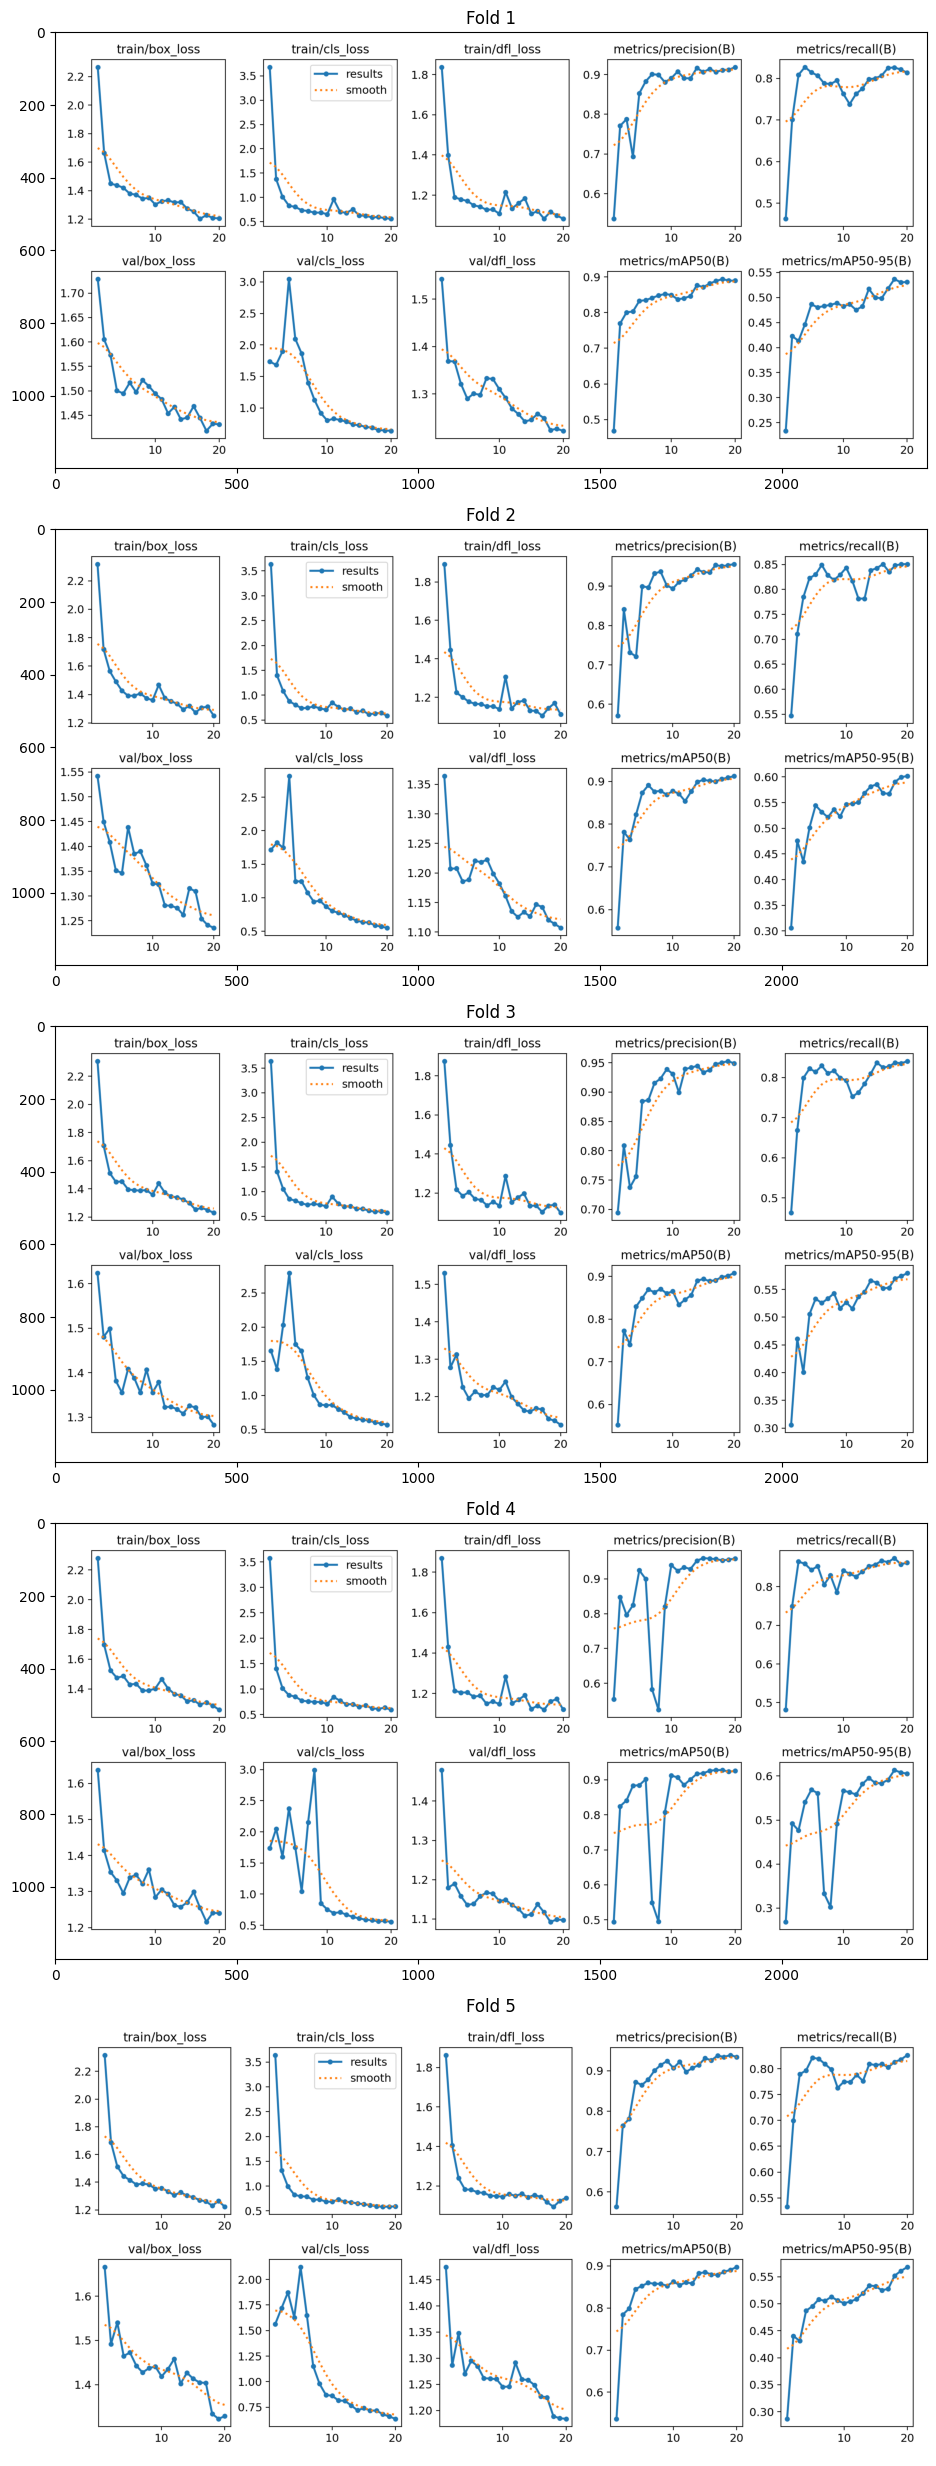

In [9]:
img1 = np.asarray(Image.open("KFold_training_barnacles_SFT/fold_1/results.png"))
img2 = np.asarray(Image.open("KFold_training_barnacles_SFT/fold_2/results.png"))
img3 = np.asarray(Image.open("KFold_training_barnacles_SFT/fold_3/results.png"))
img4 = np.asarray(Image.open("KFold_training_barnacles_SFT/fold_4/results.png"))
img5 = np.asarray(Image.open("KFold_training_barnacles_SFT/fold_5/results.png"))

fig, axes = plt.subplots(5,1, figsize=(25,25))

#fold1
axes[0].imshow(img1) 
axes[0].set_title('Fold 1')

#fold2
axes[1].imshow(img2) 
axes[1 ].set_title('Fold 2')

#fold3
axes[2].imshow(img3) 
axes[2].set_title('Fold 3')

#fold4
axes[3].imshow(img4)
axes[3].set_title('Fold 4')

#fold5
axes[4].imshow(img5) 
axes[4].set_title('Fold 5')


plt.tight_layout()
plt.axis('off')
plt.show()

<font size=5>Observations</font>

<font size=4> The training and validation loss curves generally show a consistent downward trend across epochs, indicating that the model is learning. While some variation exists between the folds, this is expected due to the small dataset size and the lightweight architecture of the model.

In particular, the second fold displays a consistent spike in losses during the early epochs. This could point to a non-uniform distribution of images across the folds, where the second validation set might contain more challenging or less representative examples. With a larger and more diverse dataset, these irregularities might smooth out, leading to more stable and generalizable training curves.
</font>

<font size=5><u>Next Steps:</u></font>

<font size=4> Given the observed variation in model performance across folds, I decided the most robust approach for generating final predictions on unseen data would be to ensemble all the trained models. This allows me to utilize the strengths of each fold-specific model and reduce the variance in predictions.

For inference, I employed a method called Slicing Aided Hyper Inference (SAHI). SAHI is an open-source framework specifically designed to improve detection of small or densely packed objects by slicing the input image into overlapping patches. Each patch is analyzed individually, enabling the model to better capture fine-grained details that might be missed in a full-frame inference. For a detailed read on SAHI, you can explore this [article](https://encord.com/blog/slicing-aided-hyper-inference-explained/).

Since the models were trained on 256×256-sized patches, I used the same patch dimensions during inference to maintain consistency and optimize performance. SAHI is well-supported within the YOLO ecosystem, making it straightforward to integrate into my pipeline.
</font>

<font size=6><u>Initializing and Ensembling</u></font>

<font size=4.5> For inference, I utilize the five models trained during the 5-fold cross-validation process. Given the small dataset size and the high variability in image content, ensembling provides a practical way to improve prediction accuracy by reducing model-specific biases.
Due to time constraints, I was unable to explore more sophisticated ensembling techniques. Instead, I implemented a simple yet effective approach: averaging the predictions from all five models. While rudimentary, this method still uses the diverse learnings of the individual folds and offers a meaningful performance boost over using a single model alone.
</font>

In [10]:

def sahi_inference(image_filepath, model): 
    
    result = get_sliced_prediction(
        image_filepath,
        model, slice_height=256,
        slice_width=256,
        postprocess_match_metric="IOU",
        postprocess_match_threshold=0.4,
        overlap_height_ratio=0.2,
        postprocess_class_agnostic = True,
        overlap_width_ratio=0.2,
        )
    return result


<font size =6><u>Image 1<u>

In [13]:
numbers_1 =[]

for i in range(5): 
    model=  AutoDetectionModel.from_pretrained(
        model_type = "yolov8", 
        model_path = f'KFold_training_barnacles_SFT/fold_{i+1}/best.pt', 
        confidence_threshold=0.5, 
        device ="cpu")
    result = sahi_inference("../unseen_images/unseen_img1.png", model)
    object_predictionlist = result.object_prediction_list
    number = len(object_predictionlist)
    numbers_1.append(number)
    
mean_value_1 = sum(numbers_1) / len(numbers_1)

print(f"The prediced number of barnacles in this image is {mean_value_1}")


Performing prediction on 64 slices.
Performing prediction on 64 slices.
Performing prediction on 64 slices.
Performing prediction on 64 slices.
Performing prediction on 64 slices.
The prediced number of barnacles in this image is 1242.4


<font size =6><u>Image 2<u>

In [15]:
numbers_2 =[]

for i in range(5): 
    model=  AutoDetectionModel.from_pretrained(
        model_type = "yolov8", 
        model_path = f'KFold_training_barnacles_SFT/fold_{i+1}/best.pt', 
        confidence_threshold=0.5, 
        device ="cpu")
    result = sahi_inference("../unseen_images/unseen_img2.png", model)
    object_predictionlist = result.object_prediction_list
    number = len(object_predictionlist)
    numbers_2.append(number)
    
mean_value_2 = int(sum(numbers_2) / len(numbers_2))
print(f"The prediced number of barnacles in this image is {mean_value_2}")


Performing prediction on 9 slices.
Performing prediction on 9 slices.
Performing prediction on 9 slices.
Performing prediction on 9 slices.
Performing prediction on 9 slices.
The prediced number of barnacles in this image is 153
